In [1]:
!pip install transformers
!pip install torch
!pip install pandas
!pip install sqlalchemy pyodbc
!pip install scikit-learn
!pip install pdfminer.six


  Obtaining dependency information for scipy>=1.5.0 from https://files.pythonhosted.org/packages/b9/8b/7ec1832b09dbc88f3db411f8cdd47db04505c4b72c99b11c920a8f0479c3/scipy-1.15.2-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00:01
     -------------------- ------------------- 30.7/60.8 kB 1.4 MB/s eta 0:00

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datashader 0.15.2 requires numba, which is not installed.


In [2]:
import pyodbc
import pandas as pd

# Identifiants de connexion (à adapter si besoin)
server = 'LAPTOP-BJE2TQGI\\KK'  # attention à l’échappement du backslash
database = 'abc'

# Connexion via Windows Authentication
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(conn_str)
    print("✅ Connexion réussie !")

    # Charger la table Dim_job dans un DataFrame
    query = "SELECT TOP 100 * FROM Dim_job"
    df_jobs = pd.read_sql(query, conn)

    # Afficher un aperçu
    display(df_jobs[['title', 'company', 'location']].head())

    conn.close()

except Exception as e:
    print("❌ Erreur de connexion :", e)


C:\Users\USER\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Connexion réussie !


C:\Users\USER\AppData\Local\Temp\ipykernel_1792\3559317547.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_jobs = pd.read_sql(query, conn)


,title,company,location
0,Ingénieur / Ingénieure réseau informatique,Adhesif Elastique Adhe-Els,"Kalaâ Kebira, Sousse"
1,Ingénieur / Ingénieure logiciel informatique,PwC,Tunis
2,Ingénieur / Ingénieure de développement inform...,Company Not Found,Sidi Bouzid
3,Ingénieur de Développement Informatique .NET /...,Netcom Active Services,Tunis
4,Ingénieur informaticien / Ingénieure informati...,STE OMH TRAVEL SERVICE SARL,Monastir


In [10]:
from pdfminer.high_level import extract_text

def extract_text_from_pdf(file_path):
    text = extract_text(file_path)
    return text

# Utilisation avec raw string
text_cv = extract_text_from_pdf(r"C:\Users\USER\Desktop\Ayari-Khalil.pdf")

# Affichage des premières lignes
print(text_cv[:500])


Ayari Khalil
Etudiant en Ingénierie Informatique

+216 27444792
khalil.ayari@esprit.tn  

PROFIL

Etudiant en 3 ème année cycle préparatoire a ESPRIT ingénieur ,ayant une capacité
d’organisation et de prise d’initiative ainsi que de connaissances avancées en
développement web et programmation . Je suis indépendant et créatif . 

PROJETS ACADÉMIQUES

FORMATION SCOLAIRE

Développement d'un jeu 2D 
Langage C , GIT HUB , Arduino, Linux

Projet QT
 Projet intégré comportant les compétences
suivante: 


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

cleaned_text = clean_text(text_cv)


In [6]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("camembert-base")
model = AutoModel.from_pretrained("camembert-base")

def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

cv_embedding = get_embedding(cleaned_text)


C:\Users\USER\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:133: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


C:\Users\USER\anaconda3\Lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [16]:
def ats_score(text):
    keywords = ['python', 'machine learning', 'sql', 'flask', 'deep learning', 'pandas']
    score = sum(1 for kw in keywords if kw in text.lower())
    return round((score / len(keywords)) * 100, 2)

score_cv = ats_score(cleaned_text)
print(f"📝 Score ATS : {score_cv} %")


📝 Score ATS : 33.33 %


                                                title                 company  \
40  Stage PFE élève ingénieur - Développement Web ...                  MAT-IT   
3   Ingénieur de Développement Informatique .NET /...  Netcom Active Services   
17  Ingénieur Base de Données SQL Server - Spécial...               STACKWAZE   
67                    Data Engineer senior Python F/H                Devoteam   
80         Chef de Projet Industriel (COFAT Kairouan)          Groupe Elloumi   

    similarity_score  
40          0.874057  
3           0.852912  
17          0.852670  
67          0.836447  
80          0.836320  


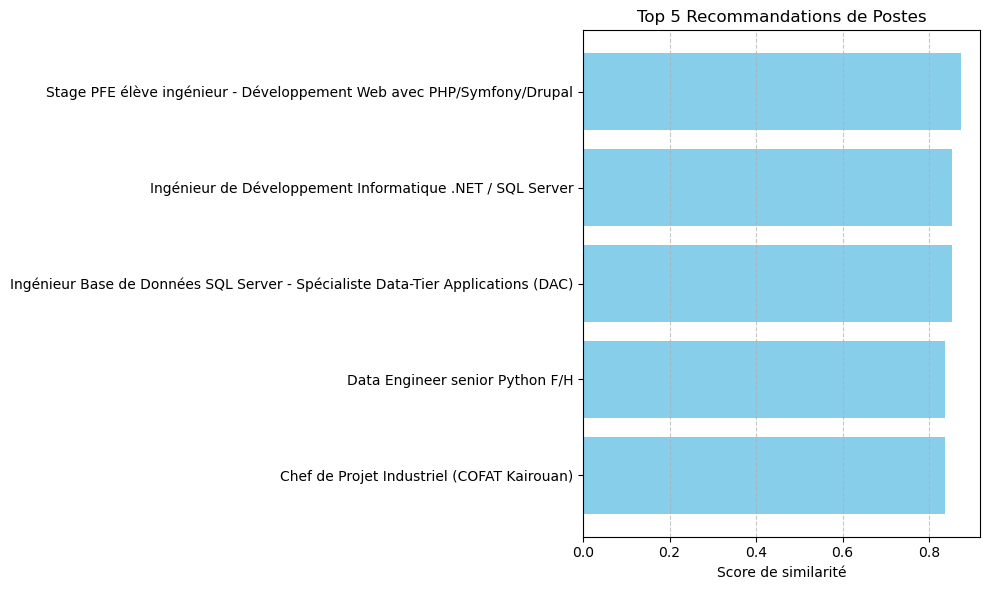

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def compute_job_embeddings(job_titles):
    """
    Calcule les embeddings pour une liste de titres de postes.
    """
    return [get_embedding(clean_text(title)) for title in job_titles]

# Récupération et nettoyage des titres de postes
job_titles = df_jobs['title'].fillna('').tolist()

# Calcul des embeddings des titres
job_embeddings = compute_job_embeddings(job_titles)

# Calcul des similarités entre le CV et les offres
similarity_scores = cosine_similarity([cv_embedding], job_embeddings)[0]

# Ajout des scores à la DataFrame
df_jobs['similarity_score'] = similarity_scores

# Top 5 recommandations
top_recommendations = df_jobs.sort_values(by='similarity_score', ascending=False).head(5)

# Affichage des résultats dans la console
print(top_recommendations[['title', 'company', 'similarity_score']])

# ---------- Visualisation ----------
plt.figure(figsize=(10, 6))
plt.barh(top_recommendations['title'], top_recommendations['similarity_score'], color='skyblue')
plt.xlabel('Score de similarité')
plt.title('Top 5 Recommandations de Postes')
plt.gca().invert_yaxis()  # Inverser l’ordre pour avoir le meilleur score en haut
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [9]:
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.route('/analyze', methods=['POST'])
def analyze():
    file = request.files['file']
    text = extract_text(file)
    cleaned = clean_text(text)
    embedding = get_embedding(cleaned)
    ats = ats_score(cleaned)

    similarities = cosine_similarity([embedding], job_embeddings)[0]
    df_jobs['score'] = similarities
    top5 = df_jobs.sort_values(by='score', ascending=False).head(5)

    result = {
        "ats_score": ats,
        "top_titles": top5['title'].tolist(),
        "top_companies": top5['company'].tolist()
    }
    return jsonify(result)

# Pour lancer le serveur Flask
# app.run(debug=True)
